## Import library and samples

In [32]:
#import libraries and define figures repo
import scanpy as sc
import os
import numpy as np
sc.settings.figdir = "figures/"


In [ ]:
#change wd
os.getcwd()
os.chdir("/Users/annacarolinafagundes/ibd-myeloid-scoring/") 


In [34]:
#list files of directory
data_dir = "data/raw/scrna"
for filename in os.listdir(data_dir):
    print(filename)

GSM6614364_CD-5
GSM6614349_HC-2
GSM6614360_CD-1
.DS_Store
GSM6614352_HC-5
GSM6614362_CD-3
GSM6614358_UC-5
GSM6614363_CD-4
GSM6614355_UC-2
GSM6614353_HC-6
GSM6614356_UC-3
GSE214695_cell_annotation.csv
GSM6614357_UC-4
GSM6614361_CD-2
GSM6614348_HC-1
GSM6614365_CD-6
GSM6614354_UC-1
GSM6614351_HC-4
GSM6614359_UC-6
GSM6614350_HC-3


### Extract sample names and create new folder for each sample

In [49]:
#create new folder for each sample and skip annotation file
for filename in os.listdir(data_dir):
    
    # skip non-sample files
    if not filename.endswith(".gz"):
        continue
    
    # extract sample name and file type
    parts = filename.split("_")
    sample_name = parts[0] + "_" + parts[1]
    file_type = parts[2]

    print(sample_name, file_type)
    
     # create sample folder if it doesn't exist
    sample_dir = os.path.join(data_dir, sample_name)
    os.makedirs(sample_dir, exist_ok=True)
    
    # move and rename the file
    old_path = os.path.join(data_dir, filename)
    new_path = os.path.join(sample_dir, file_type)
    os.rename(old_path, new_path)

In [ ]:
#read matrices
adata = sc.read_10x_mtx(
    "data/raw/scrna/GSM6614348_HC-1",
    var_names="gene_symbols",
    cache=True
)
print(adata)

AnnData object with n_obs × n_vars = 737280 × 33538
    var: 'gene_ids', 'feature_types'


: 

In [ ]:
#anndata structure
print(adata.obs) #cells (barcode symbols)
print(adata.var) #gene names
print(adata.X) #count matrix

Empty DataFrame
Columns: []
Index: [AAACCTGAGAAACCAT-1, AAACCTGAGAAACCGC-1, AAACCTGAGAAACCTA-1, AAACCTGAGAAACGAG-1, AAACCTGAGAAACGCC-1, AAACCTGAGAAAGTGG-1, AAACCTGAGAACAACT-1, AAACCTGAGAACAATC-1, AAACCTGAGAACTCGG-1, AAACCTGAGAACTGTA-1, AAACCTGAGAAGAAGC-1, AAACCTGAGAAGATTC-1, AAACCTGAGAAGCCCA-1, AAACCTGAGAAGGACA-1, AAACCTGAGAAGGCCT-1, AAACCTGAGAAGGGTA-1, AAACCTGAGAAGGTGA-1, AAACCTGAGAAGGTTT-1, AAACCTGAGAATAGGG-1, AAACCTGAGAATCTCC-1, AAACCTGAGAATGTGT-1, AAACCTGAGAATGTTG-1, AAACCTGAGAATTCCC-1, AAACCTGAGAATTGTG-1, AAACCTGAGACAAAGG-1, AAACCTGAGACAAGCC-1, AAACCTGAGACAATAC-1, AAACCTGAGACACGAC-1, AAACCTGAGACACTAA-1, AAACCTGAGACAGACC-1, AAACCTGAGACAGAGA-1, AAACCTGAGACAGGCT-1, AAACCTGAGACATAAC-1, AAACCTGAGACCACGA-1, AAACCTGAGACCCACC-1, AAACCTGAGACCGGAT-1, AAACCTGAGACCTAGG-1, AAACCTGAGACCTTTG-1, AAACCTGAGACGACGT-1, AAACCTGAGACGCAAC-1, AAACCTGAGACGCACA-1, AAACCTGAGACGCTTT-1, AAACCTGAGACTAAGT-1, AAACCTGAGACTACAA-1, AAACCTGAGACTAGAT-1, AAACCTGAGACTAGGC-1, AAACCTGAGACTCGGA-1, AAACCTGAGACTGGGT-1, AAAC

: 

In [48]:
#create anndata object for each folder and filter empty droplets (for memory saving purposes)
adatas = []
for sample in os.listdir(data_dir):
    if not sample.startswith("GSM"):
        continue
    print(f"Loading {sample}...")
    adata = sc.read_10x_mtx(
        os.path.join(data_dir, sample),
        var_names="gene_symbols",
        cache=True #First time: scanpy reads the .gz files, decompresses them, then saves a processed copy as an .h5ad file in the same folder
    )
    #here I would run scrublet normally, but due to processing constraints had to skip
    # filter empty barcodes immediately
    counts_per_barcode = np.asarray(adata.X.sum(axis=1)).flatten()
    adata = adata[counts_per_barcode > 500] #total read counts per droplet
    # add sample column to metadata
    adata.obs["sample"] = sample  
    # add condition column to metadata
    condition = sample.split("_")[1].split("-")[0] #first split ["GSM6614348", "HC-1"] and takes "HC-1" then split it and takes "HC"
    adata.obs["condition"] = condition 
    print(f"  Kept {adata.n_obs} cells")
    #append list
    adatas.append(adata)


Loading GSM6614364_CD-5...


/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_981/385019724.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 2038 cells
Loading GSM6614349_HC-2...


/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_981/385019724.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 4309 cells
Loading GSM6614360_CD-1...


...

  Kept 4864 cells
Loading GSM6614359_UC-6...


/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_981/385019724.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 4171 cells
Loading GSM6614350_HC-3...


/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_981/385019724.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 6518 cells


In [ ]:
#Inspect if the dimensions look fine
for i, adata in enumerate(adatas):
    print(i, adata.n_obs)

: 

### Filtering and QC

In [ ]:
#check if samples are unique 
for adata in adatas:
    print(adata.obs["sample"].unique())


In [ ]:
#merge samples into one object and perform sanity check
adata_combined = sc.concat(adatas)
print(adata_combined)
adata_combined.obs["condition"].value_counts()


In [ ]:
#save unfiltered, processed object
adata_combined.write("data/processed/adata_combined_raw.h5ad")


In [ ]:
# if needed delete unnecessary objects (memory management)
del adatas          # delete the list — no longer needed
del counts_per_barcode
del adata

In [ ]:
#detect mitochondrial, ribosimal and hemoglobin genes
adata_combined.var["mt"] = adata_combined.var_names.str.startswith("MT-")
adata_combined.var["ribo"] = adata_combined.var_names.str.startswith(("RPS", "RPL"))
adata_combined.var["hb"] = adata_combined.var_names.str.contains("^HB[^(P)]")

In [ ]:
#inspect number of genes
print("MT genes:", adata_combined.var["mt"].sum())
print("Ribo genes:", adata_combined.var["ribo"].sum())
print("HB genes:", adata_combined.var["hb"].sum())

MT genes: 13
Ribo genes: 104
HB genes: 12


In [ ]:
#calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata_combined,
    qc_vars=["mt", "ribo", "hb"], #flag genes in var, stores results as pct in obs
    inplace=True, #replace the object instead of creating a new one
    log1p=True)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
#export to visualize data structure
adata_combined.obs.to_csv("obs_check.csv") #object metatada/ rows:barcode / cols: metadata cols
adata_combined.var.to_csv("var_check.csv") #gene metadata/ rows: gene / cols: mean counts


In [ ]:
#visualize QC metrics general
sc.pl.violin(
    adata_combined,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    size=0.4,
    multi_panel=True,
    save="_qc_violin.png" #because we already set the figures repo in the beginning
)

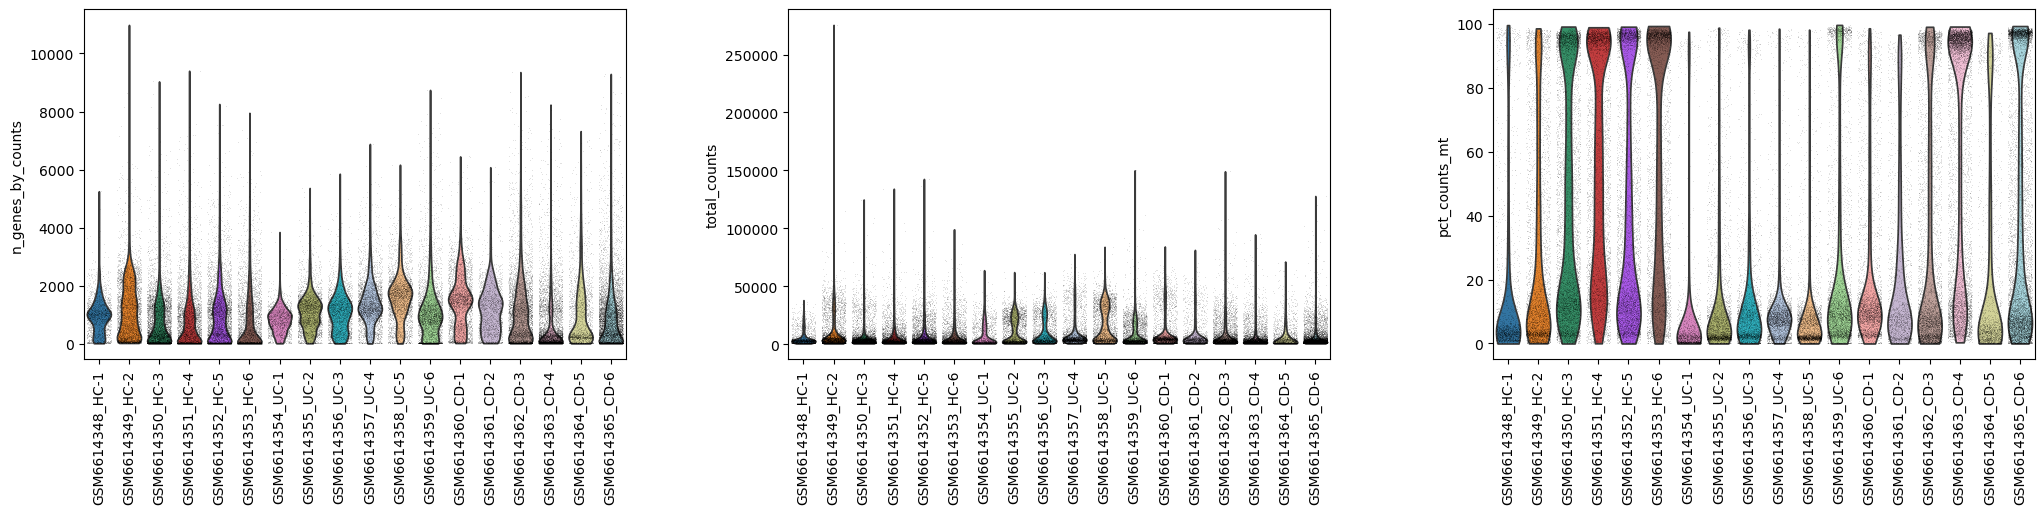

In [ ]:
#visualize QC metrics per sample
sc.pl.violin(
    adata_combined,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    size=0.2,
    groupby="sample",
    save="_qc_violin_per_sample.png",
    rotation=90)


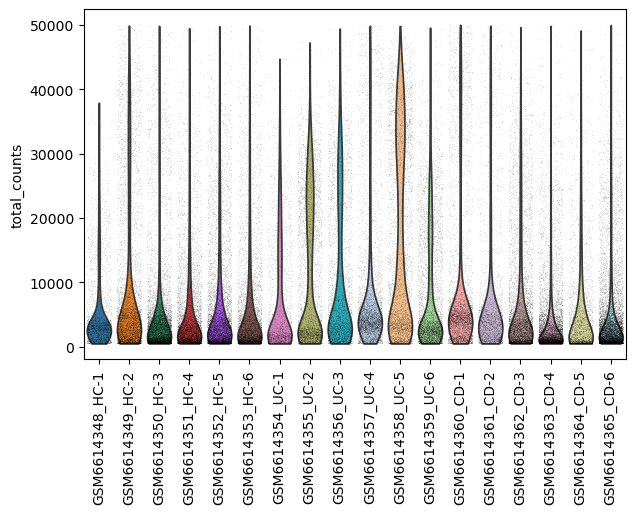

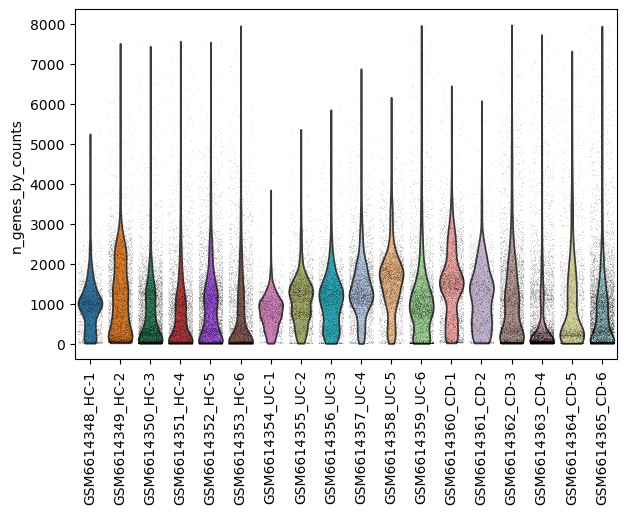

In [ ]:
#adjust ylim to visualize ncounts and n_genes_by_counts properly
sc.pl.violin(
    adata_combined[adata_combined.obs["total_counts"] < 50000],
    ["total_counts"],
    jitter=0.4,
    size=0.2,
    groupby="sample",
    save="_qc_total_counts_zoom.png",
    rotation=90)

sc.pl.violin(
    adata_combined[adata_combined.obs["n_genes_by_counts"] < 8000],
    ["n_genes_by_counts"],
    jitter=0.4,
    size=0.2,
    groupby="sample",
    save="_qc_genes_zoom.png",
    rotation=90)


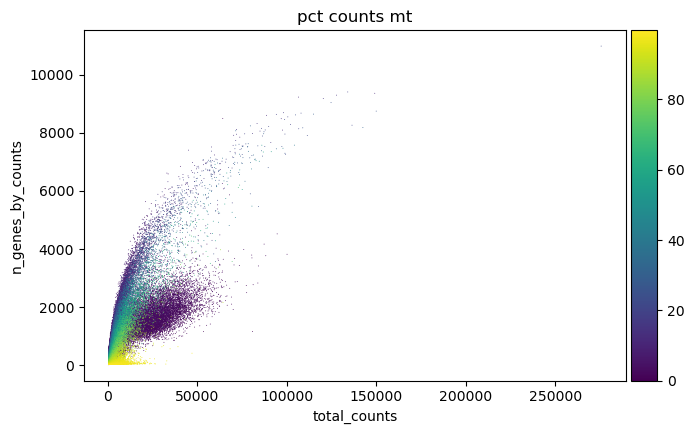

In [46]:
#visualize QC metrics 
sc.pl.scatter(adata_combined, "total_counts", 
"n_genes_by_counts", 
color="pct_counts_mt",
save="_qc_scatter.png")

In [ ]:
#filter dead cells and doublets

adata_combined_filtered=adata_combined[(adata_combined.obs["total_counts"] < 15000) &
(adata_combined.obs["total_counts"] > 500) & 
(adata_combined.obs["pct_counts_mt"] < 20) &
(adata_combined.obs["n_genes_by_counts"] > 200) &
(adata_combined.obs["n_genes_by_counts"] < 6000)
]

In [40]:
#check number of cells before and after filtering
print(adata_combined.obs.shape)
print(adata_combined_filtered.obs.shape)

(75489, 19)
(30325, 19)


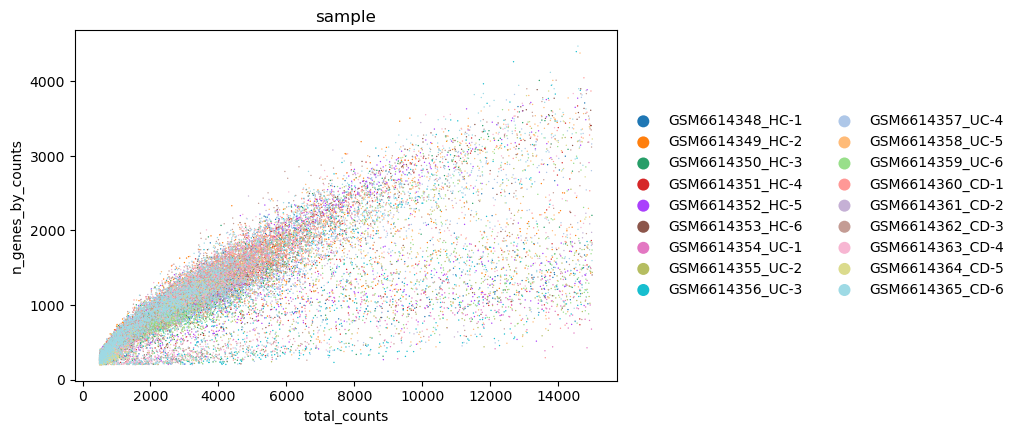

In [ ]:
#visualize QC metrics again
sc.pl.scatter(adata_combined_filtered, "total_counts", 
"n_genes_by_counts", 
color="sample",
save="_qc_filtered_scatter.png")

## Normalization and feature selection

In [52]:
# Saving count data
adata_combined_filtered.layers["counts"] = adata_combined_filtered.X.copy()

/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_981/2129215603.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_combined_filtered.layers["counts"] = adata_combined_filtered.X.copy()
/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [53]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_combined_filtered)
# Logarithmize the data
sc.pp.log1p(adata_combined_filtered)

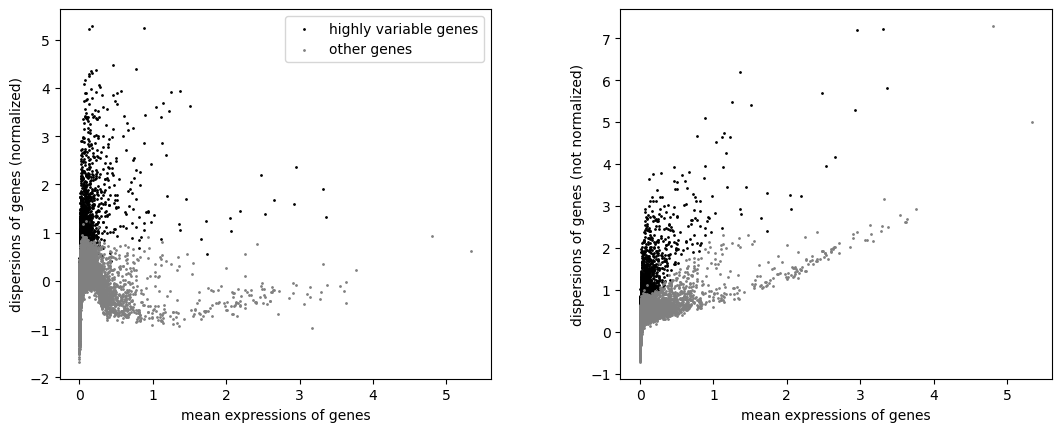

In [57]:
#Feature selection
sc.pp.highly_variable_genes(adata_combined_filtered, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata_combined_filtered,
save=".png")

In [58]:
#save filtered object
adata_combined_filtered.write("data/processed/adata_combined_filtered.h5ad")
print("Saved!")

Saved!
